# Práctica 1: Perceptrón multicapa.

Tu jefe pidió a RH que recolectara datos de desempeño de tus compañeros, los resultados se almacenaron en un csv. El punto critico de estos datos es la satisfacción del empleado, entonces ¿Podremos estimar la satisfacción de los empleados con los datos recabados?.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

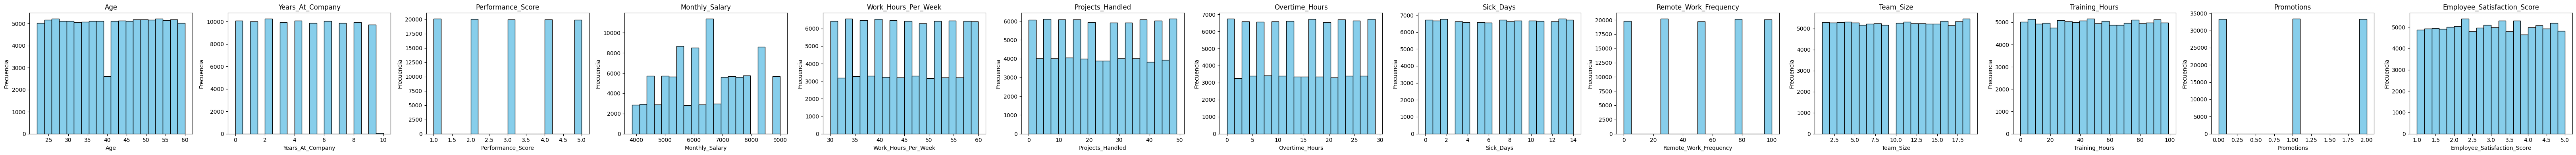

In [ ]:
# Filtrar las columnas numéricas
numeric_columns = df.select_dtypes(include=['number']).drop('Employee_ID', axis=1)

# Si numeric_columns es un Index, conviértelo a lista
cols = list(numeric_columns)

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Problemas**, tenemos distribuciones con picos, esos nos indica categorías. Por otro lado, tenemos variables con "valles" en su distribución (distribuciones multimodales) por lo que resultaría óptimo aplicar técnicas de feature engeneering. Por último tenemos distribuciones uniformes, por lo que cada una requeriría un procesamiento indivudual, hagamos la vista gorda e intentemos ajustar un MLP con estos datos, solo estandaricemos nuestros datos.

---

## Implementación de Red:

Tomemos los datos numéricos como nuestra variable X, y la variable objetivo como ***'Employee_Satisfaction_Score'***.
- **Actividad 1**: Para todos los strings `'@modif@'` que aparescan en el siguiente bloque de código cámbialos para que el código funcione.

In [ ]:
X = numeric_columns.drop('Employee_Satisfaction_Score', axis=1)
y = numeric_columns['Employee_Satisfaction_Score']
y = y.apply(lambda x: round(x) - 1) # Cambiamos la variable objetivo a 5 categorías numéricas

scaler = StandardScaler()
X_standar = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_standar, y, test_size=0.33, random_state=42)

y_onehot_train = tf.keras.utils.to_categorical(y_train, 5)
y_onehot_test = tf.keras.utils.to_categorical(y_test, 5)

- **Actividad 2:** Implementa 3 arquitecturas de MLP, cada una con su propio nombre, cambiando la estructura de dichas arquitecturas (capas, neuronas por capa, función de activación, etc).

In [ ]:
# Modelo 1: Arquitectura Básica (1 capa oculta de 32 neuronas con activación ReLU)
model_basic = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='MLP_Basic')

# Modelo 2: Arquitectura Intermedia (2 capas ocultas con Dropout)
model_medium = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(5, activation='softmax')
], name='MLP_Medium')

# Modelo 3: Arquitectura Profunda (3 capas ocultas con Batch Normalization, LeakyReLU y Dropout)
model_deep = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.3),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.3),
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.1),
    layers.Dense(5, activation='softmax')
], name='MLP_Deep')

model_basic.summary()
model_medium.summary()
model_deep.summary()

Model: "MLP_Basic"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 581 (2.27 KB)
 Trainable params: 581 (2.27 KB)
 Non-trainable params: 0 (0.00 B)


Model: "MLP_Medium"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           832 │
├───────────────

- **Actividad 3:** Compila y ajusta tus tres modelos con sus respectivos hiperparámetros.

In [ ]:
# Compilación de los 3 modelos con diferentes hiperparámetros
model_basic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_medium.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

model_deep.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

epochs = 15
batch_size = 64

print("=== Entrenando Modelo Básico ===")
history_basic = model_basic.fit(X_train, y_onehot_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_onehot_test), verbose=1)

print("\n=== Entrenando Modelo Intermedio ===")
history_medium = model_medium.fit(X_train, y_onehot_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_onehot_test), verbose=1)

print("\n=== Entrenando Modelo Profundo ===")
history_deep = model_deep.fit(X_train, y_onehot_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_onehot_test), verbose=1)

=== Entrenando Modelo Básico ===
Epoch 1/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1s 430us/step - accuracy: 0.2423 - loss: 1.5976 - val_accuracy: 0.2556 - val_loss: 1.5633
Epoch 2/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.2583 - loss: 1.5594 - val_accuracy: 0.2514 - val_loss: 1.5611
Epoch 3/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.2601 - loss: 1.5569 - val_accuracy: 0.2506 - val_loss: 1.5603
Epoch 4/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.2577 - loss: 1.5571 - val_accuracy: 0.2487 - val_loss: 1.5610
Epoch 5/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - accuracy: 0.2618 - loss: 1.5564 - val_accuracy: 0.2528 - val_loss: 1.5603
Epoch 6/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.2677 - loss: 1.5548 - val_accuracy: 0.2496 - val_loss: 1.5605
Epoch 7/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.2637 - loss: 1.5547 - val_accuracy: 0.2501 - val_loss: 1.5603
Epoch 8/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 0

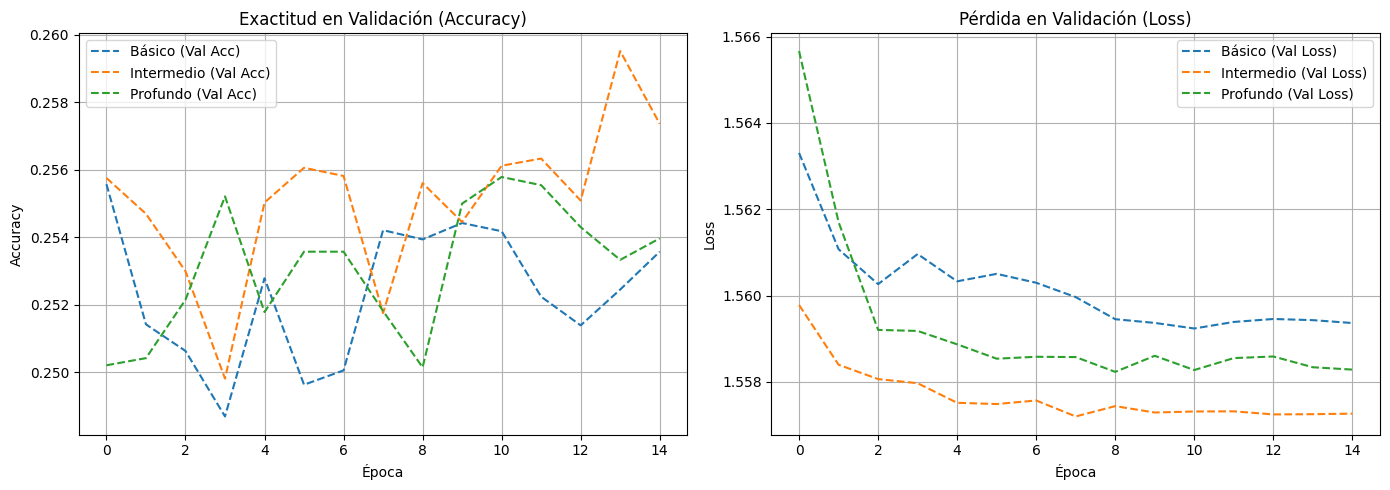

Modelo Básico     -> Test Loss: 1.5594, Test Accuracy: 0.2536
Modelo Intermedio -> Test Loss: 1.5573, Test Accuracy: 0.2574
Modelo Profundo   -> Test Loss: 1.5583, Test Accuracy: 0.2540


In [ ]:
# Evaluación y Gráficas Comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(history_basic.history['val_accuracy'], label='Básico (Val Acc)', linestyle='--')
axes[0].plot(history_medium.history['val_accuracy'], label='Intermedio (Val Acc)', linestyle='--')
axes[0].plot(history_deep.history['val_accuracy'], label='Profundo (Val Acc)', linestyle='--')
axes[0].set_title('Exactitud en Validación (Accuracy)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Loss
axes[1].plot(history_basic.history['val_loss'], label='Básico (Val Loss)', linestyle='--')
axes[1].plot(history_medium.history['val_loss'], label='Intermedio (Val Loss)', linestyle='--')
axes[1].plot(history_deep.history['val_loss'], label='Profundo (Val Loss)', linestyle='--')
axes[1].set_title('Pérdida en Validación (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluación final en conjunto de prueba
loss_b, acc_b = model_basic.evaluate(X_test, y_onehot_test, verbose=0)
loss_m, acc_m = model_medium.evaluate(X_test, y_onehot_test, verbose=0)
loss_d, acc_d = model_deep.evaluate(X_test, y_onehot_test, verbose=0)

print(f"Modelo Básico     -> Test Loss: {loss_b:.4f}, Test Accuracy: {acc_b:.4f}")
print(f"Modelo Intermedio -> Test Loss: {loss_m:.4f}, Test Accuracy: {acc_m:.4f}")
print(f"Modelo Profundo   -> Test Loss: {loss_d:.4f}, Test Accuracy: {acc_d:.4f}")

- **Actividad 4:** Sube tus cambios al repositorio, envía el link de tu repositorio a la actividad 2 de tu checkpoint 2 y contesta las preguntas de dicha actividad.